In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

In [2]:
import logging
import pandas as pd
import matplotlib.pyplot as plt

from context import CRMPromoContext

from data.db import get_gp_connection
from data.loaders import (
    load_orders_with_geo,
    load_customers,
    load_segments,
)
from data.builders import build_promo_dataset

from config.settings import DB_CONFIG
from config.promo_types import PromoMechanicType

from pipelines.crm_pipeline import run_crm_pipeline

from evaluation.plots import (
    plot_propensity_distribution,
    plot_uplift_distribution,
)

### Параметры акции

In [3]:
PROMO_CODE = "ВЕСНАЦВЕТЕТ"

PROMO_START = "2026-02-26"
PROMO_END = "2026-03-26"

LOAD_START = "2026-01-20"
LOAD_END = "2026-04-15"

### Загрузка данных

In [4]:
with get_gp_connection(**DB_CONFIG) as conn:

    
    # =====================================================
    # 1. PROMO ORDERS (treated)
    # =====================================================

    promo_orders = load_orders_with_geo(
        conn,
        LOAD_START,
        LOAD_END,
        promo_code=PROMO_CODE,
        only_promo=True,
    )

    print("PROMO ORDERS:", promo_orders.shape)

    # =====================================================
    # 2. CONTROL ORDERS
    # =====================================================

    control_orders = load_orders_with_geo(
        conn,
        LOAD_START,
        LOAD_END,
        promo_code=None,
        only_promo=False,
        sample_fraction=0.002,
        limit=50_000,
    )

    print("CONTROL ORDERS:", control_orders.shape)

    # =====================================================
    # 3. UNION
    # =====================================================

    orders = pd.concat(
        [
            promo_orders,
            control_orders,
        ],
        ignore_index=True,
    )

    print("TOTAL ORDERS:", orders.shape)

    # =====================================================
    # 4. CUSTOMERS
    # =====================================================
    
    active_rks = (
        orders["customer_rk"]
        .astype(str)
        .unique()
    )
    
    customers = load_customers(
        conn,
        customer_rks=active_rks,
    )

    print("CUSTOMERS:", customers.shape)

    # =====================================================
    # 5. SEGMENTS
    # =====================================================

    segments = load_segments(
        conn,
        cutoff_date=PROMO_START
    )

    print("SEGMENTS:", segments.shape)

/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/data/loaders.py:150: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(
DEBUG LIMIT ENABLED: 50,000
SQL SAMPLE ENABLED: 0.20%


PROMO ORDERS: (17165, 7)


/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/data/loaders.py:150: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(


CONTROL ORDERS: (50000, 7)
TOTAL ORDERS: (67165, 7)


/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/data/loaders.py:242: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


CUSTOMERS: (316351, 2)


/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/data/loaders.py:327: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


SEGMENTS: (21872880, 5)


### Проверка 

In [5]:
print(orders.shape)
print(customers.shape)
print(segments.shape)

orders.head()

(67165, 7)
(316351, 2)
(21872880, 5)


,order_id,customer_rk,created_dttm,paid_wo_bonuses_amt,discount_amt,promo_code,city
0,fc1a8a03-20b1-4840-a198-d050b83f0e0b,d5ce3823151e91b6dd432d4fceab41c4,2026-03-23 14:15:09.073,1104.0,0.0,ВЕСНАЦВЕТЕТ,Москва
1,4d3a2f34-347f-4ceb-87ae-f48dda7b7180,52a53e21487e7de3fa7991ec62a1a4a5,2026-03-11 08:28:34.208,5007.0,0.0,ВЕСНАЦВЕТЕТ,Москва
2,94c9649b-09f8-47a0-8b36-07c54e1321e3,238637573974d11e4c611bf79ee400e7,2026-03-13 10:59:58.979,1042.0,0.0,ВЕСНАЦВЕТЕТ,Москва
3,29c0db1d-0132-42d4-8b26-043fc1ef63b0,d5dd39cec44c7f4b52b3c867ba30b60a,2026-03-17 09:36:34.965,2035.0,0.0,ВЕСНАЦВЕТЕТ,Москва
4,8d7ccf99-b978-497d-b4ce-87f56959482a,a8988b246d6698db4ad7372e49707e7e,2026-03-14 17:48:54.475,1056.0,0.0,ВЕСНАЦВЕТЕТ,Москва


### Проверка промо

In [6]:
orders["is_promo"] = (
    orders["promo_code"] == PROMO_CODE
).astype(int)

orders["is_promo"].mean()

np.float64(0.2556539864512767)

In [7]:
df = build_promo_dataset(
    orders=orders,
    customers=customers,
    segments=segments,
    promo_code=PROMO_CODE,
    promo_start=PROMO_START,
    promo_end=PROMO_END,
    pre_period_days=30,
    post_period_days=14,
)

df.shape

(37730, 15)

In [8]:
df.head()

,customer_rk,revenue_pre,revenue_post,y,T,customer_id,customer_segment,age,gender,report_date,home_city,orders_cnt,revenue_sum,avg_check,discount_share
0,b5f91d99ea80b2e7cc9f123c21e9f74f,1962.0,0.0,0.0,0,735898116,Базовый 2,Возраст_35_39,Мужской пол,2026-01-31,Красноярск,1,1962.0,1962.0,0.0
1,dd578b78302dee3c2b57fa325ac8865f,484.0,0.0,0.0,0,880988947,Подростки и студенты,Возраст_21,Женский пол,2026-01-31,Барнаул,1,484.0,484.0,0.0
2,cc3fab8c3025873f50c3410e160ba14f,1915.0,0.0,0.0,0,12556485,Базовый 1,Возраст_30_34,Мужской пол,2026-01-31,Новокузнецк,1,1915.0,1915.0,0.0
3,cc17bf600c780323eb12447e47ab1a06,1165.0,0.0,0.0,0,806504457,Базовый 1,Возраст_25_29,Женский пол,2026-01-31,Москва,1,1165.0,1165.0,0.0
4,7014ad0fa95a412b1ab4cde826ca9959,690.0,0.0,0.0,0,1401558188,Базовый 2,Возраст_40_44,Женский пол,2026-01-31,Москва,1,690.0,690.0,0.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37730 entries, 0 to 37729
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   customer_rk       37730 non-null  string       
 1   revenue_pre       37730 non-null  float64      
 2   revenue_post      37730 non-null  float64      
 3   y                 37730 non-null  float64      
 4   T                 37730 non-null  int64        
 5   customer_id       37141 non-null  string       
 6   customer_segment  37730 non-null  string       
 7   age               37730 non-null  string       
 8   gender            37730 non-null  string       
 9   report_date       31729 non-null  datetime64[s]
 10  home_city         37730 non-null  string       
 11  orders_cnt        37730 non-null  int64        
 12  revenue_sum       37730 non-null  float64      
 13  avg_check         37730 non-null  float64      
 14  discount_share    37730 non-null  float64      
d

### Создание контекста

In [10]:
ctx = CRMPromoContext(
    mechanic_type=PromoMechanicType.CRM,

    promo_name="Весна Цветет 2026",

    orders_df=orders,
    customers_df=customers,
    segments_df=segments,

    promo_code=PROMO_CODE,

    promo_start=PROMO_START,
    promo_end=PROMO_END,

    pre_period_days=30,
    post_period_days=14,
)

### Запуск пайплайна

In [11]:
result = run_crm_pipeline(
    ctx,
    debug_mode=False,
)

⚠️ Overlap Violation Detected: Extreme propensity scores found.
Low overlap detected. Causal estimates may be unstable.
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWar

### Результаты

In [12]:
print("Incremental Revenue:")
print(result["incremental_revenue"])

print()

print("95% CI:")
print(result["ci_95"])
ci_lower, ci_upper = result["ci_95"]

if (
    ci_lower is not None
    and ci_upper is not None
):

    if ci_lower > 0:

        print(
            "Effect is statistically positive."
        )

    elif ci_upper < 0:

        print(
            "Effect is statistically negative."
        )

    else:

        print(
            "Effect is not statistically significant."
        )

print()

print("ATE DML:")
print(result["ate_dml"])

Incremental Revenue:
1469.7321642725938

95% CI:
(None, None)

ATE DML:
None


### Диагностика

In [13]:
result["treatment_summary"]
result["overlap_result"]
result["balance_table"]

,control_mean,treated_mean,abs_diff
revenue_pre,972.190346,1207.739126,235.548780
revenue_sum,972.190346,1207.739126,235.548780
orders_cnt,1.006658,1.016393,0.009735
avg_check,977.277926,1206.368852,229.090926


### Графики

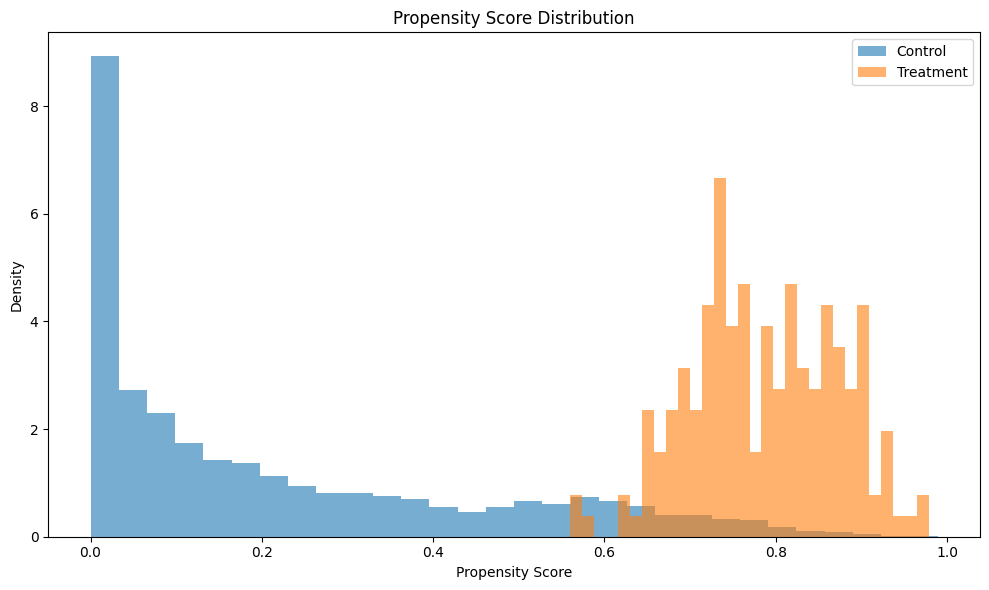

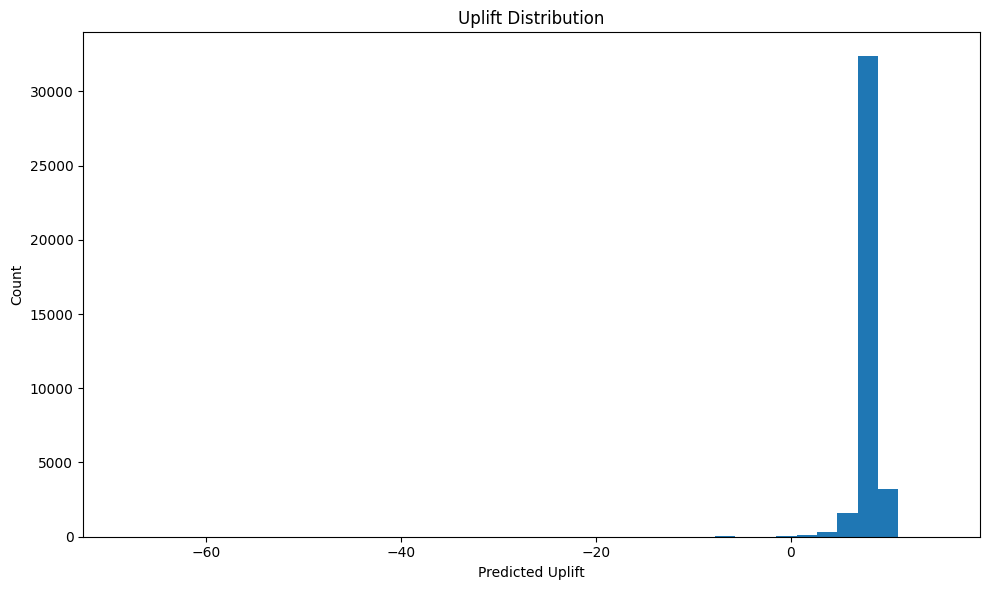

In [14]:
plot_propensity_distribution(
    result["df_predictions"]
)

plot_uplift_distribution(
    result["df_predictions"]
)

### Top uplift клиенты

In [15]:
result["df_predictions"] \
    .sort_values("uplift", ascending=False) \
    .head(20)

,customer_rk,revenue_pre,revenue_post,y,T,customer_id,report_date,orders_cnt,revenue_sum,avg_check,...,age_Возраст_55_59,age_Возраст_60_69,age_Возраст_70_79,age_Возраст_больше_80,gender_Женский пол,gender_Мужской пол,propensity_score,uplift,tau_0_pred,tau_1_pred
13689,7587b1721944f1dd6734250e196d2647,1773.00,0.0,0.0,1,52415730,2026-01-31,1,1773.00,1773.0,...,0,0,0,0,0,1,0.897152,15.269297,16.126836,7.788902
4091,d66b383f5efbe6657c4324c1dab7fda4,3495.42,0.0,0.0,0,1131996246,2026-01-31,1,3495.42,4126.0,...,0,0,0,0,0,1,0.683077,13.972144,16.840948,7.788902
4749,cbf1b45ce8090ef745f640806d398769,1127.00,0.0,0.0,0,1062091496,2026-01-31,1,1127.00,1127.0,...,0,0,0,0,0,1,0.649292,13.816351,17.072011,7.788902
25063,cc7eca2beb5f313afa16c7c42168434b,2585.00,0.0,0.0,0,69553378,2026-01-31,1,2585.00,2585.0,...,0,0,0,0,0,1,0.655302,13.700542,16.810149,7.788902
15293,dacd27d4b0edcb8ca89451fe82da327d,955.00,0.0,0.0,0,677264095,2026-01-31,1,955.00,955.0,...,0,0,0,0,0,1,0.582930,13.282159,17.212426,7.788902
9843,32590e6dd02d701e4935bc794dbf1bc0,1048.00,0.0,0.0,0,897977769,2026-01-31,1,1048.00,1048.0,...,0,0,0,0,0,1,0.482533,12.403229,17.351613,7.788902
12089,a7c7331378c7d0a66dc14c91d6d40765,1012.00,0.0,0.0,0,970451611,2026-01-31,1,1012.00,1012.0,...,0,0,0,0,0,1,0.473240,12.314357,17.351613,7.788902
32506,50bd5804d1d5f6c5922b0fc81ec06e4b,817.00,0.0,0.0,0,12166231,2026-01-31,1,817.00,817.0,...,0,0,0,0,0,1,0.445620,11.916454,17.051404,7.788902
7612,b2d2e44d6e373cd98ad4555a4dd74da4,1997.00,0.0,0.0,0,66743468,2026-01-31,1,1997.00,1997.0,...,0,0,0,0,0,1,0.471912,11.795219,16.278442,7.788902
26917,d36a25574d74d5afd20125c67ab7c890,943.00,0.0,0.0,1,808226960,2026-01-31,1,943.00,943.0,...,0,0,0,0,0,1,0.690976,11.631300,13.349732,7.788902


### Сохранение результатов

In [17]:
pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 35.9 MB/s  0:00:01 eta 0:00:010:01
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pyarrow as pa
import pyarrow.parquet as pq

table = pa.Table.from_pandas(result["df_predictions"])
pq.write_table(table, "../artifacts/vesna_uplift.parquet")